In [2]:
import umap

2026-03-30 14:54:05.912294: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-30 14:54:06.706644: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import glob
import anndata

# load data

In [4]:
# sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
# sc.logging.print_header()
# sc.settings.set_figure_params(dpi=80, facecolor='white')

In [5]:
import pandas as pd
import scanpy as sc

# File path provided by the user
file_path = '/media/data2/samba/ssong/data/Tac1/dendrite1axon.xlsx'

# Load the data from Excel
data = pd.read_excel(file_path)

# Split the data into `obs` (metadata) and `X` (count data)
obs = data.iloc[:, :2].copy()  # First two columns as metadata (obs)
X = data.iloc[:, 2:].copy()  # Remaining columns as count data (var)

# Create an AnnData object
adata = sc.AnnData(X=X, obs=obs)

# # Save the AnnData object for later use
# output_path = '/media/data2/samba/ssong/data/Tac1/dendrite1.h5ad'
# adata.write(output_path)


/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/anndata/utils.py:292: UserWarning: X converted to numpy array with dtype float64
  warnings.warn(f"{name} converted to numpy array with dtype {arr.dtype}")
/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [5]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer

In [6]:
X = adata.X.copy()
print(X.shape)

(24, 56)


In [7]:
features_exclude = ['Afterdepolarization (mV)', 'AP Fano factor', 'ISI Fano factor', 
                    'Latency @ +20pA current (ms)', 'Wildness', 'Spike frequency adaptation',
                    'Sag area (mV*s)', 'Sag time (s)', 'Burstiness',
                    'AP amplitude average adaptation index', 'ISI average adaptation index',
                    'Rebound number of APs']
features_log = ['AP coefficient of variation', 'ISI coefficient of variation', 
                'ISI adaptation index', 'Latency (ms)']


In [8]:
for e in features_log:
    X[:, adata.var.index==e] = np.log(X[:, adata.var.index==e])

# X = X[:, ~np.isin(adata.var.index, features_exclude)]

In [9]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [10]:
keep_cells = ~np.isnan(np.sum(X, axis=1))
X = X[keep_cells, :]
print(X.shape)

(24, 56)


In [11]:
X = X - X.mean(axis=0)
X = X / X.std(axis=0)

/tmp/ipykernel_697849/3681760069.py:2: RuntimeWarning: invalid value encountered in true_divide
  X = X / X.std(axis=0)


In [12]:
nan_cols = np.all(np.isnan(X), axis=0)

In [13]:
X = X[:, ~nan_cols]

In [14]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

In [15]:
PC_init = PCA(n_components=2, svd_solver='full').fit_transform(X)
PC_init = PC_init / np.std(PC_init[:, 0]) * 0.0001

In [16]:
adata = adata[keep_cells]

In [17]:
umap_obj = umap.UMAP(init=PC_init, n_neighbors=10, min_dist=0.5, random_state=42)
embedding = umap_obj.fit_transform(X)

In [18]:
umap_obj = umap.UMAP(init=PC_init, n_neighbors=5, min_dist=0.1, metric='euclidean',random_state=42)
embedding = umap_obj.fit_transform(X)

In [19]:
adata.obsm['X_umap'] = embedding

/tmp/ipykernel_697849/2657750689.py:1: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
  adata.obsm['X_umap'] = embedding


In [20]:
adata

AnnData object with n_obs × n_vars = 24 × 56
    obs: 'File Name', 'type'
    obsm: 'X_umap'

/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/media/data2/samba/ssong/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


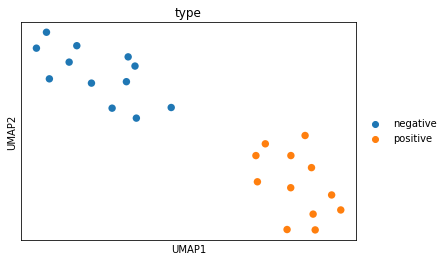

In [87]:
sc.pl.umap(adata, color='type', size=220)

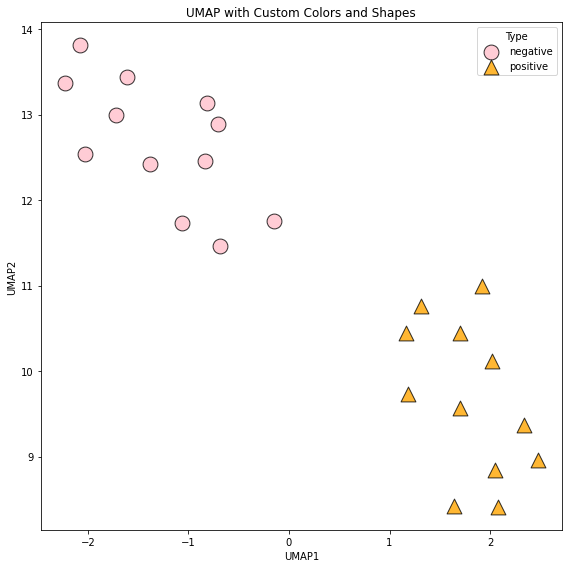

'/media/data2/samba/ssong/data/Tac1/dendrite1_custom.svg'

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define a color and marker map for better visualization
color_map = {'positive': 'orange', 'negative': 'pink'}
marker_map = {'positive': '^', 'negative': 'o'}

# Extract UMAP coordinates and labels
umap1 = adata.obsm['X_umap'][:, 0]
umap2 = adata.obsm['X_umap'][:, 1]
labels = adata.obs['type']

# Plot UMAP with custom colors and markers
plt.figure(figsize=(8, 8))
for label in np.unique(labels):
    mask = labels == label
    plt.scatter(umap1[mask], umap2[mask], 
                color=color_map[label], 
                marker=marker_map[label], 
                label=label, 
                s=220, 
                edgecolor='k', 
                alpha=0.8)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP with Custom Colors and Shapes")
plt.legend(title="Type")
plt.grid(False)
plt.tight_layout()

# Save the improved plot
output_path = '/media/data2/samba/ssong/data/Tac1/dendrite1_custom.svg'
plt.savefig(output_path, format='svg', bbox_inches='tight')
plt.show()

output_path


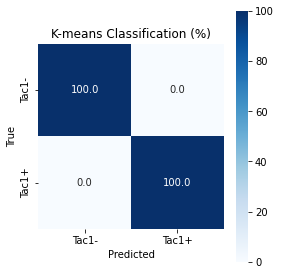

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


X = adata.X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.array(X, dtype=float)
X = StandardScaler().fit_transform(X)

y_true = adata.obs['type'].astype(str).reset_index(drop=True)

kmeans = KMeans(n_clusters=2, random_state=10, n_init=100)
clusters = kmeans.fit_predict(X).astype(str)

mapping = {}
for c in np.unique(clusters):
    majority_label = y_true[np.array(clusters) == c].value_counts().idxmax()
    mapping[c] = majority_label

y_pred = pd.Series(clusters).map(mapping)

cm = confusion_matrix(y_true, y_pred, labels=['negative', 'positive'], normalize='true') * 100
cm_df = pd.DataFrame(cm, index=['Tac1-', 'Tac1+'], columns=['Tac1-', 'Tac1+'])

plt.figure(figsize=(4, 4))
sns.heatmap(cm_df, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100, square=True, cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("K-means Classification (%)")
plt.tight_layout()
plt.show()